In [19]:
from brainstorm.download import download_train_validation_data

# Download all training and validation data
train_features, train_labels, val_features, val_labels = download_train_validation_data()

# Data is saved to ./data/ and returned as pandas DataFrames
print(f"Training features shape: {train_features.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Validation features shape: {val_features.shape}")
print(f"Validation labels shape: {val_labels.shape}")

Training features shape: (90386, 1024)
Training labels shape: (90386, 1)
Validation features shape: (22596, 1024)
Validation labels shape: (22596, 1)


In [ ]:
# from tqdm import tqdm
# for sample in tqdm(val_features.values, desc="Predicting", leave=False):
#     print(sample.shape)
#     break

(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)
(1024,)


In [21]:
# Convert to tensors
import torch
import numpy as np

X=train_features.values
y=train_labels["label"].values

class_to_idx = {c: i for i, c in enumerate(np.unique(y))}

X_tensor = torch.tensor(X, dtype=torch.float32)
y_indices = np.array([class_to_idx[label] for label in y])
y_tensor = torch.tensor(y_indices, dtype=torch.long)

print(X_tensor.shape, y_tensor.shape)

# Create data loader
dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
loader = torch.utils.data.DataLoader(
    dataset, batch_size=64, shuffle=True
)

torch.Size([90386, 1024]) torch.Size([90386])


In [26]:
next(iter(loader))[0].shape

torch.Size([64, 1024])

In [12]:
# Seem like the same data, just a different way of loading it
from pathlib import Path
from brainstorm.loading import load_raw_data

DATA_PATH = Path("./data")

# Load training data
train_features, train_labels = load_raw_data(DATA_PATH, step="train")

# Load validation data
validation_features, validation_labels = load_raw_data(DATA_PATH, step="validation")

display(train_features)
display(train_labels)
display(validation_features)
display(validation_labels)


2026-01-23 15:01:44.861 | INFO     | brainstorm.loading:load_raw_data:38 - Loading data from: data
2026-01-23 15:01:45.003 | INFO     | brainstorm.loading:load_raw_data:50 - Features shape: (90386, 1024)
2026-01-23 15:01:45.003 | INFO     | brainstorm.loading:load_raw_data:51 - Labels shape: (90386, 1)
2026-01-23 15:01:45.004 | INFO     | brainstorm.loading:load_raw_data:54 - Features time range: 0.0 to 90.385
2026-01-23 15:01:45.004 | INFO     | brainstorm.loading:load_raw_data:57 - Labels time range: 0.0 to 90.385
2026-01-23 15:01:45.008 | INFO     | brainstorm.loading:load_raw_data:38 - Loading data from: data
2026-01-23 15:01:45.067 | INFO     | brainstorm.loading:load_raw_data:50 - Features shape: (22596, 1024)
2026-01-23 15:01:45.067 | INFO     | brainstorm.loading:load_raw_data:51 - Labels shape: (22596, 1)
2026-01-23 15:01:45.068 | INFO     | brainstorm.loading:load_raw_data:54 - Features time range: 90.387 to 112.982
2026-01-23 15:01:45.068 | INFO     | brainstorm.loading:load

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0.000,52.552498,22.571249,71.077499,35.294998,85.994995,70.151245,42.266251,84.093750,90.772499,55.575001,...,737.294983,1005.371216,8.444962e+02,522.599976,810.956238,695.467529,600.209961,874.623779,559.065002,923.032471
0.001,32.223747,-2.681250,50.943748,9.993751,77.756248,59.426247,7.897500,60.888752,49.773750,4.582500,...,891.296265,1180.676270,9.781688e+02,674.309998,925.811279,808.908752,711.506226,994.646240,679.087524,1067.917480
0.002,30.273750,-18.281250,41.681252,-10.968750,69.225006,49.529999,-11.017500,58.500000,45.337502,-4.777500,...,969.296265,1256.775024,1.040520e+03,752.895020,998.205017,886.323730,792.723755,1061.775024,763.278748,1147.672607
0.003,25.154999,-29.396250,33.247501,-12.577500,66.933746,45.776249,-20.621250,50.651249,41.145000,-7.800000,...,1011.854980,1303.428711,1.086686e+03,805.837524,1039.398682,935.414978,846.251282,1110.866211,815.099976,1197.982422
0.004,24.911249,-33.101250,31.687500,-21.059999,60.840000,38.366249,-24.911251,45.678749,35.831249,-11.992500,...,1050.708740,1337.066284,1.098874e+03,848.493774,1063.042480,963.251282,879.255005,1139.921265,844.301270,1224.063721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90.381,-6.191250,-3.900000,-3.607500,-15.258750,-8.531250,-8.190000,-10.822500,-1.170000,-13.455000,-9.408750,...,-6.435000,-13.552500,-4.387500e+00,-19.353750,-7.507500,-10.627501,-17.208750,-3.120000,-9.213750,-3.120000
90.382,-8.677500,-3.558750,-3.022500,-10.383750,-6.435000,-7.507500,-13.260000,-11.992500,-12.382500,-5.362500,...,-5.167500,-14.673750,-5.362500e+00,-9.603750,-6.386250,-5.313750,-12.723750,-1.267500,-11.163750,-12.285000
90.383,-11.358750,-4.290000,-3.851250,-9.213751,-6.142500,-3.948750,-14.235000,-6.678750,-10.773750,-5.606250,...,-8.726250,-14.332500,-9.457500e+00,-19.792500,-3.461250,-3.607500,-17.501251,-1.901249,-7.946250,-3.412500
90.384,-5.850000,-4.923750,-2.047500,-2.437500,-5.021250,-2.876250,-11.163750,-6.483750,-7.117500,-4.436250,...,-10.188749,-8.628750,-3.022500e+00,-16.526249,-3.607500,-8.482500,-12.918750,-0.926250,-13.211250,-7.361250


,label
time_s,
0.000,0.0
0.001,0.0
0.002,0.0
0.003,0.0
0.004,0.0
...,...
90.381,5195.0
90.382,5195.0
90.383,5195.0


,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
90.387,-9.360000,-6.045000,-3.900000,-9.360000,-10.432500,-7.702500,-17.355000,-7.800000,-12.675000,-8.092500,...,-8.336250,-11.504999,-1.316250,-10.286250,-4.582500,-3.851250,-15.599999,8.287500,-2.681250,2.047500
90.388,-7.702500,-0.682500,-2.096250,-8.580000,-7.361250,-7.848750,-12.236250,-7.605000,-8.775000,-2.632500,...,-15.746250,-12.870000,-8.531250,-8.872499,-1.657500,-5.216250,-17.549999,10.286249,-5.703750,0.292500
90.389,-8.580000,-5.070000,-7.946250,0.292500,-11.797500,-6.483750,-15.843750,-9.408751,-11.163750,-5.167500,...,-16.575001,-13.650000,-14.040000,-10.286250,-13.113750,-12.382500,-18.622499,2.486250,-13.893750,-2.827500
90.390,-11.309999,-8.433750,-5.557500,-1.218750,-11.748750,-11.163750,-12.090000,-9.262500,-13.650000,-2.535000,...,-21.303749,-4.192500,-13.113750,-28.323750,-23.790001,-21.937500,-19.743750,2.437500,-10.286250,-9.993751
90.391,-20.816250,-14.088750,-9.165001,-13.016250,-17.939999,-13.162500,-14.137501,-16.331249,-17.891251,-9.067500,...,-33.052498,-7.653750,-18.281250,-28.860001,-26.861250,-25.203751,-27.933750,-8.580000,-17.647499,-16.477501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112.978,89.163750,-2.388750,22.181250,15.258750,87.116249,-1.901250,14.235000,44.167500,23.448750,-5.703750,...,17.598751,-22.132500,-33.345001,46.361252,-28.421251,7.946250,59.133751,-68.055000,27.446249,-40.608749
112.979,95.891251,9.750000,35.099998,27.885000,96.866249,7.507500,24.862499,53.771252,38.025002,4.582500,...,20.718750,-39.243752,-37.488750,52.503750,-25.350000,9.360000,66.933746,-70.589996,40.706249,-37.878750
112.980,109.784996,23.205000,54.502502,42.022499,109.005005,20.962500,35.051250,72.150002,51.285000,23.010000,...,19.938751,-42.558750,-43.631248,58.207500,-28.762501,8.823750,70.785004,-76.781250,42.119999,-47.580002
112.981,108.322502,34.807499,61.278751,58.646252,115.196251,32.369999,45.142502,74.392502,64.154999,35.051250,...,19.597500,-50.748749,-40.998749,72.442497,-27.299999,15.795000,72.686249,-81.900002,55.477501,-71.418747


,label
time_s,
90.387,5195.0
90.388,5195.0
90.389,5195.0
90.390,5195.0
90.391,5195.0
...,...
112.978,789.0
112.979,789.0
112.980,789.0


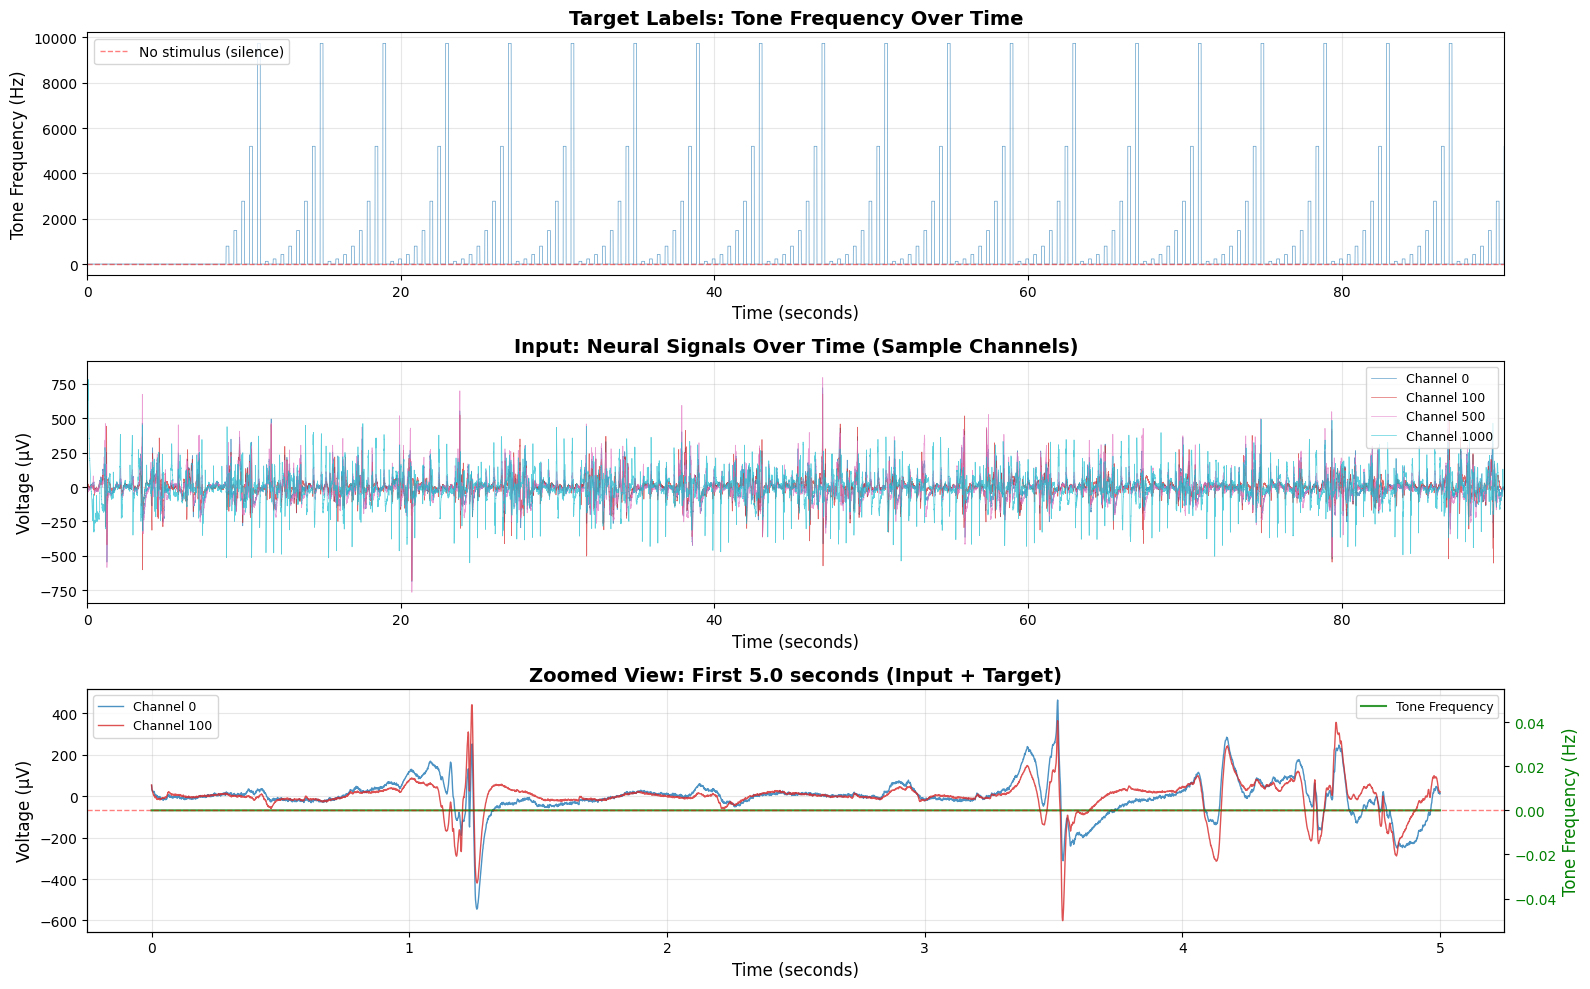


Dataset Statistics:
Total duration: 90.39 seconds
Sampling rate: 1000 Hz (1 ms per sample)
Number of channels: 1024

Label Statistics:
Unique tone frequencies: [np.float64(120.0), np.float64(224.0), np.float64(421.0), np.float64(789.0), np.float64(1479.0), np.float64(2772.0), np.float64(5195.0), np.float64(9736.0)]
Silence periods (label=0): 60454 samples (66.9%)
Stimulus periods (label>0): 29932 samples (33.1%)


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Create comprehensive plots showing input and target
fig = plt.figure(figsize=(16, 10))

# Plot 1: Labels over time (target)
ax1 = plt.subplot(3, 1, 1)
time = train_labels.index.values
labels = train_labels['label'].values
ax1.plot(time, labels, linewidth=0.5, alpha=0.7)
ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_ylabel('Tone Frequency (Hz)', fontsize=12)
ax1.set_title('Target Labels: Tone Frequency Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.5, label='No stimulus (silence)')
ax1.legend()
ax1.set_xlim([time[0], time[-1]])

# Plot 2: Neural signals over time for a few representative channels (input)
ax2 = plt.subplot(3, 1, 2)
# Select a few channels to plot (e.g., channels 0, 100, 500, 1000)
selected_channels = [0, 100, 500, 1000]
colors = plt.cm.tab10(np.linspace(0, 1, len(selected_channels)))

for i, ch in enumerate(selected_channels):
    signal = train_features.iloc[:, ch].values
    ax2.plot(time, signal, label=f'Channel {ch}', linewidth=0.5, alpha=0.7, color=colors[i])

ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Voltage (μV)', fontsize=12)
ax2.set_title('Input: Neural Signals Over Time (Sample Channels)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlim([time[0], time[-1]])

# Plot 3: Zoomed-in view of a specific time window showing both input and target
ax3 = plt.subplot(3, 1, 3)
# Select a time window (e.g., first 5 seconds)
time_window = 5.0
mask = time <= time_window
time_zoom = time[mask]
labels_zoom = labels[mask]

# Plot labels
ax3_twin = ax3.twinx()
ax3_twin.plot(time_zoom, labels_zoom, 'g-', linewidth=1.5, alpha=0.8, label='Tone Frequency')
ax3_twin.set_ylabel('Tone Frequency (Hz)', fontsize=12, color='g')
ax3_twin.tick_params(axis='y', labelcolor='g')
ax3_twin.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.5)

# Plot neural signals for a few channels
for i, ch in enumerate(selected_channels[:2]):  # Just show 2 channels for clarity
    signal_zoom = train_features.iloc[mask, ch].values
    ax3.plot(time_zoom, signal_zoom, label=f'Channel {ch}', linewidth=1, alpha=0.8, color=colors[i])

ax3.set_xlabel('Time (seconds)', fontsize=12)
ax3.set_ylabel('Voltage (μV)', fontsize=12)
ax3.set_title(f'Zoomed View: First {time_window} seconds (Input + Target)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Print some statistics
print("\nDataset Statistics:")
print(f"Total duration: {time[-1]:.2f} seconds")
print(f"Sampling rate: {1000} Hz (1 ms per sample)")
print(f"Number of channels: {train_features.shape[1]}")
print(f"\nLabel Statistics:")
print(f"Unique tone frequencies: {sorted([f for f in np.unique(labels) if f > 0])}")
print(f"Silence periods (label=0): {np.sum(labels == 0)} samples ({np.sum(labels == 0)/len(labels)*100:.1f}%)")
print(f"Stimulus periods (label>0): {np.sum(labels > 0)} samples ({np.sum(labels > 0)/len(labels)*100:.1f}%)")

In [11]:
from pathlib import Path
from brainstorm.loading import load_raw_data
from brainstorm.evaluation import ModelEvaluator
from brainstorm.ml.logistic_regression import LogisticRegression

DATA_PATH = Path("./data")
train_features, train_labels = load_raw_data(DATA_PATH, step="train")
validation_features, validation_labels = load_raw_data(DATA_PATH, step="validation")

# Train your model
model = LogisticRegression(input_size=train_features.shape[1], max_iter=20, use_pca=True)
model.fit(X=train_features.values, y=train_labels["label"].values)

# Evaluate on validation set
evaluator = ModelEvaluator(
    test_features=validation_features,
    test_labels=validation_labels[["label"]],
)
evaluator.evaluate()

2026-01-23 14:06:30.277 | INFO     | brainstorm.loading:load_raw_data:38 - Loading data from: data
2026-01-23 14:06:30.393 | INFO     | brainstorm.loading:load_raw_data:50 - Features shape: (90386, 1024)
2026-01-23 14:06:30.393 | INFO     | brainstorm.loading:load_raw_data:51 - Labels shape: (90386, 1)
2026-01-23 14:06:30.393 | INFO     | brainstorm.loading:load_raw_data:54 - Features time range: 0.0 to 90.385
2026-01-23 14:06:30.393 | INFO     | brainstorm.loading:load_raw_data:57 - Labels time range: 0.0 to 90.385
2026-01-23 14:06:30.394 | INFO     | brainstorm.loading:load_raw_data:38 - Loading data from: data
2026-01-23 14:06:30.453 | INFO     | brainstorm.loading:load_raw_data:50 - Features shape: (22596, 1024)
2026-01-23 14:06:30.453 | INFO     | brainstorm.loading:load_raw_data:51 - Labels shape: (22596, 1)
2026-01-23 14:06:30.453 | INFO     | brainstorm.loading:load_raw_data:54 - Features time range: 90.387 to 112.982
2026-01-23 14:06:30.453 | INFO     | brainstorm.loading:load

MetricsResults(total_score=np.float64(44.83044104770073), accuracy_score=10.051218905908003, lag_score=np.float64(11.197335238609236), size_score=np.float64(23.581886903183495), accuracy=0.20102437811816007, avg_lag_samples=66.93333333333334, model_size_bytes=76542)